In [1]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic
from matplotlib.ticker import AutoMinorLocator

filename = "tree_outfile_complete_tree_overlays.root"

file = uproot.open(filename)
tree = file["outree"]

print(file.keys())
print(tree)
print(tree.num_entries)
print(tree.keys())

plane = tree["plane"].array(library="np")
hit_wires = tree["hit_wires"].array(library="np")
tot_wires = tree["tot_wires"].array(library="np")
avg_pitch = tree["avg_pitch"].array(library="np")
g4id = tree["G4ID"].array(library="np")
truth_fraction = tree["truth_fraction"].array(library="np")
max_buco = tree["max_buco"].array(library="np")

['outree;1']
<TTree 'outree' (22 branches) at 0x0001772f34d0>
1933492
['run', 'evt', 'cryo', 'tpc', 'plane', 'min_wire', 'max_wire', 'start', 'end', 'hit_wires', 'tot_wires', 'avg_pitch', 'trk_length', 'max_buco', 'whicht0', 't0PFP', 't0CRTTrack', 't0CRTHit', 'nholes', 'wire_holes', 'G4ID', 'truth_fraction']


In [2]:
def TProfile(mask) :
    average_pitch = avg_pitch[mask]
    eff = hit_wires[mask]/tot_wires[mask]

    mean_y, x_edges, binnumber = binned_statistic(average_pitch, eff, statistic='mean', bins=400, range=(0,4))
    std_y, _, _ = binned_statistic(average_pitch, eff, statistic='std', bins=400, range=(0,4))

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    counts, _ = np.histogram(average_pitch, bins=400, range=(0,4))
    err_y = std_y / np.sqrt(counts)

    return x_centers, mean_y, err_y

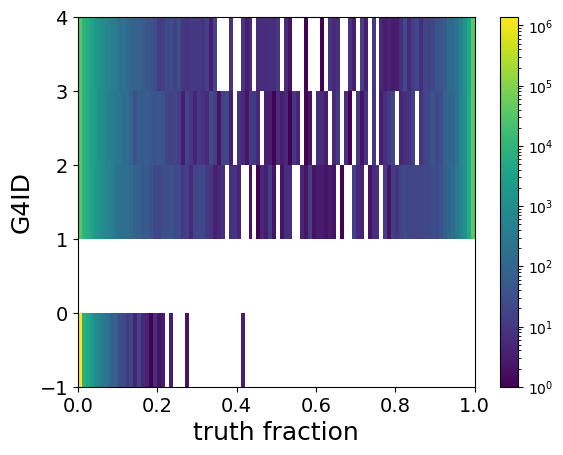

In [3]:
h = plt.hist2d(truth_fraction[max_buco < 10],g4id[max_buco < 10],bins=(100,5),range=[(0,1),(-1,4)],cmap='viridis', norm=LogNorm())
plt.xlabel('truth fraction', fontsize=18)
plt.ylabel('G4ID', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
cbar = plt.colorbar(h[3])
plt.savefig("g4id_vs_truth_fraction.pdf", format='pdf', bbox_inches='tight')

In [4]:
PLANE = 2

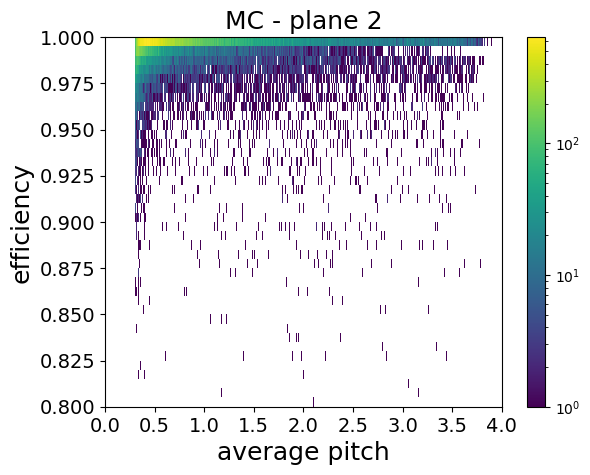

In [5]:
mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction >= 0.8) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction < 0.2) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id == -1) & (truth_fraction == 0) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id == -1) & (max_buco < 10))
h2_coll = plt.hist2d(avg_pitch[mask],hit_wires[mask]/tot_wires[mask],bins=(400,200),range=[(0,4),(0,1.0)],cmap='viridis', norm=LogNorm())
plt.xlabel('average pitch', fontsize=18)
plt.ylabel('efficiency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("MC - plane {}".format(PLANE), fontsize = 18)
cbar = plt.colorbar(h2_coll[3])
plt.ylim(0.8,1)
plt.savefig(f"plane{PLANE}_hit_efficiency_2d_MC.pdf", format = 'pdf', bbox_inches = 'tight')


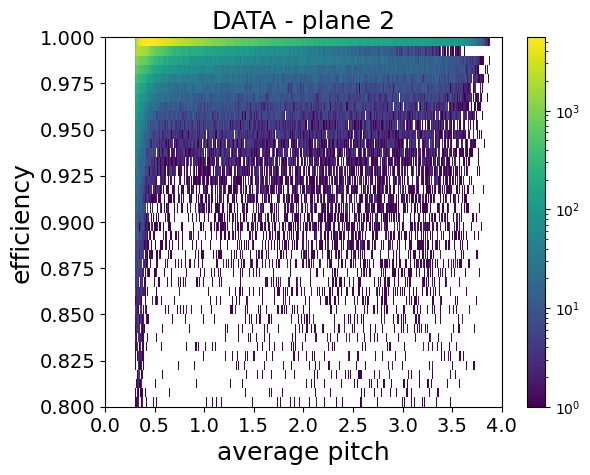

In [6]:
#mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction >= 0.8) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id != -1) & (truth_fraction < 0.2) & (max_buco < 10))
#mask = ((plane==PLANE) & (g4id == -1) & (truth_fraction == 0) & (max_buco < 10))
mask = ((plane==PLANE) & (g4id == -1) & (max_buco < 10))
h2_coll = plt.hist2d(avg_pitch[mask],hit_wires[mask]/tot_wires[mask],bins=(400,200),range=[(0,4),(0,1.0)],cmap='viridis', norm=LogNorm())
plt.xlabel('average pitch', fontsize=18)
plt.ylabel('efficiency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("DATA - plane {}".format(PLANE), fontsize = 18)
cbar = plt.colorbar(h2_coll[3])
plt.ylim(0.8,1)
plt.savefig(f"plane{PLANE}_hit_efficiency_2d_DATA.pdf", format = 'pdf', bbox_inches = 'tight')

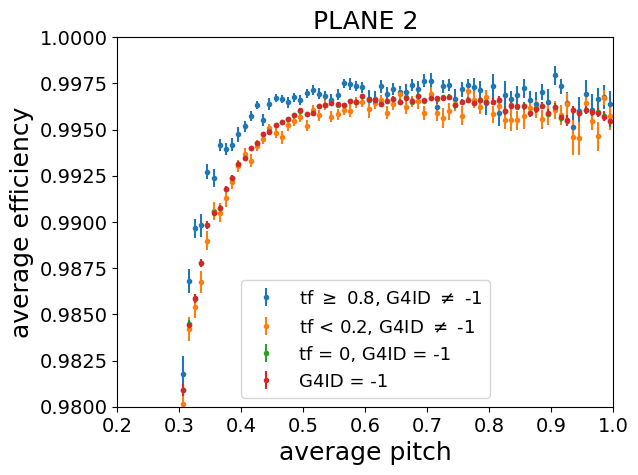

In [7]:
x_centers_MC, mean_y_MC, err_y_MC = TProfile(((plane==PLANE) & (g4id != -1) & (truth_fraction >= 0.8) & (max_buco < 10)))
x_centers_MC_low, mean_y_MC_low, err_y_MC_low = TProfile(((plane==PLANE) & (g4id != -1) & (truth_fraction < 0.2) & (max_buco < 10)))
x_centers_DATA, mean_y_DATA, err_y_DATA = TProfile(((plane==PLANE) & (g4id == -1) & (truth_fraction == 0) & (max_buco < 10)))
x_centers_DATA_all, mean_y_DATA_all, err_y_DATA_all = TProfile(((plane==PLANE) & (g4id == -1) & (max_buco < 10)))


plt.errorbar(x_centers_MC, mean_y_MC, yerr=err_y_MC, fmt='.', label = r'tf $\geq$ 0.8, G4ID $\neq$ -1')
plt.errorbar(x_centers_MC_low, mean_y_MC_low, yerr=err_y_MC_low, fmt='.', label = r'tf < 0.2, G4ID $\neq$ -1')
plt.errorbar(x_centers_DATA, mean_y_DATA, yerr=err_y_DATA, fmt='.', label = r'tf = 0, G4ID = -1')
plt.errorbar(x_centers_DATA_all, mean_y_DATA_all, yerr=err_y_DATA_all, fmt='.', label = r'G4ID = -1')
plt.xlabel('average pitch', fontsize=18)
plt.ylabel('average efficiency', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title("PLANE {}".format(PLANE), fontsize = 18)
plt.legend(loc = 'lower center', fontsize = 13)
plt.xlim(0.2,1)
plt.ylim(0.98,1)
plt.savefig(f"plane{PLANE}_truth_fraction_test.pdf", format = 'pdf', bbox_inches = 'tight')

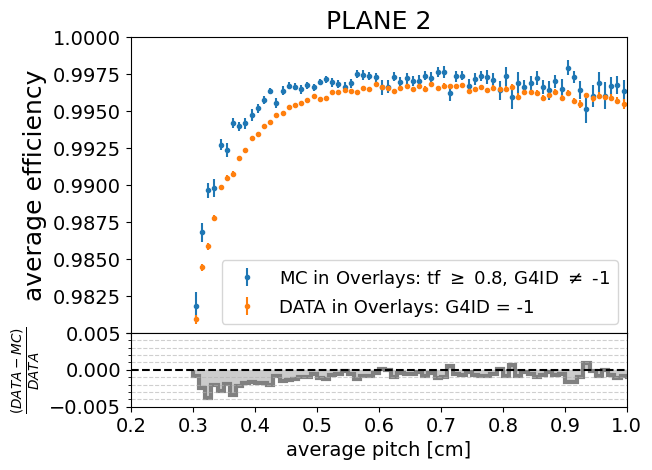

In [12]:
#data_mc_ratio = [data / mc for data,mc in zip(mean_y_DATA_all,mean_y_MC)]
data_mc_ratio = [(data - mc)/data for data,mc in zip(mean_y_DATA_all,mean_y_MC)]

fig = plt.figure()

gs = fig.add_gridspec(2, 1, height_ratios=[8,2], hspace=0)

plt.subplot(gs[0])

plt.errorbar(x_centers_MC, mean_y_MC, yerr=err_y_MC, fmt='.', label = r'MC in Overlays: tf $\geq$ 0.8, G4ID $\neq$ -1')
plt.errorbar(x_centers_DATA_all, mean_y_DATA_all, yerr=err_y_DATA_all, fmt='.', label = r'DATA in Overlays: G4ID = -1')

plt.ylabel('average efficiency', fontsize=18)
plt.yticks(fontsize=14)
ax = plt.gca()
labels = ax.get_yticklabels()
labels[0].set_visible(False)
plt.title("PLANE {}".format(PLANE), fontsize = 18)
plt.legend(loc = 'lower right', fontsize = 13)
plt.xlim(0.2,1.)
plt.ylim(0.98,1.)

plt.setp(plt.gca().get_xticklabels(), visible=False)
plt.gca().tick_params(labelbottom=False)

plt.subplot(gs[1])

dx = x_centers_MC[1] - x_centers_MC[0]

edges = np.concatenate([
    [x_centers_MC[0] - dx/2],
    x_centers_MC[:-1] + dx/2,
    [x_centers_MC[-1] + dx/2]
])

plt.stairs(data_mc_ratio,edges,fill=False,lw=3,color='gray')

#plt.fill_between(
#edges[:-1],
#1,
#data_mc_ratio,
#step='post',
#alpha=0.4,
#color='gray',
#lw=0
#)

plt.fill_between(
edges[:-1],
0,
data_mc_ratio,
step='post',
alpha=0.4,
color='gray',
lw=0
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(0.2,1.)
plt.ylim(-0.005, 0.005)

plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(axis='y', which='minor', linestyle='--', alpha=0.6)

#plt.axhline(1., color='black', linestyle='--')
plt.axhline(0., color='black', linestyle='--')
    
plt.xlabel('average pitch [cm]', fontsize=14)
plt.ylabel(r'$\frac{(DATA - MC)}{DATA}$', fontsize=14)

plt.savefig(f"plane{PLANE}_hit_efficiency_ratio.pdf", format ='pdf', bbox_inches = "tight")



In [9]:
filename_MC_1d = "tree_outfile_MC_1D.root"
filename_DATA_1d = "tree_outfile_DATA_1D_6000.root"

file_MC_1d = uproot.open(filename_MC_1d)
tree_MC_1d = file_MC_1d["outree"]

print(file_MC_1d.keys())
print(tree_MC_1d)
print(tree_MC_1d.num_entries)
print(tree_MC_1d.keys())

plane_MC_1d = tree_MC_1d["plane"].array(library="np")
hit_wires_MC_1d = tree_MC_1d["hit_wires"].array(library="np")
tot_wires_MC_1d = tree_MC_1d["tot_wires"].array(library="np")
avg_pitch_MC_1d = tree_MC_1d["avg_pitch"].array(library="np")
max_buco_MC_1d = tree_MC_1d["max_buco"].array(library="np")


file_DATA_1d = uproot.open(filename_DATA_1d)
tree_DATA_1d = file_DATA_1d["outree"]

print(file_DATA_1d.keys())
print(tree_DATA_1d)
print(tree_DATA_1d.num_entries)
print(tree_DATA_1d.keys())

plane_DATA_1d = tree_DATA_1d["plane"].array(library="np")
hit_wires_DATA_1d = tree_DATA_1d["hit_wires"].array(library="np")
tot_wires_DATA_1d = tree_DATA_1d["tot_wires"].array(library="np")
avg_pitch_DATA_1d = tree_DATA_1d["avg_pitch"].array(library="np")
max_buco_DATA_1d = tree_DATA_1d["max_buco"].array(library="np")

['outree;1']
<TTree 'outree' (17 branches) at 0x00016af1e850>
4590948
['run', 'evt', 'cryo', 'tpc', 'plane', 'min_wire', 'max_wire', 'start', 'end', 'hit_wires', 'tot_wires', 'avg_pitch', 'trk_length', 'max_buco', 'whicht0', 'nholes', 'wire_holes']
['outree;1']
<TTree 'outree' (17 branches) at 0x00016af1efd0>
5391359
['run', 'evt', 'cryo', 'tpc', 'plane', 'min_wire', 'max_wire', 'start', 'end', 'hit_wires', 'tot_wires', 'avg_pitch', 'trk_length', 'max_buco', 'whicht0', 'nholes', 'wire_holes']


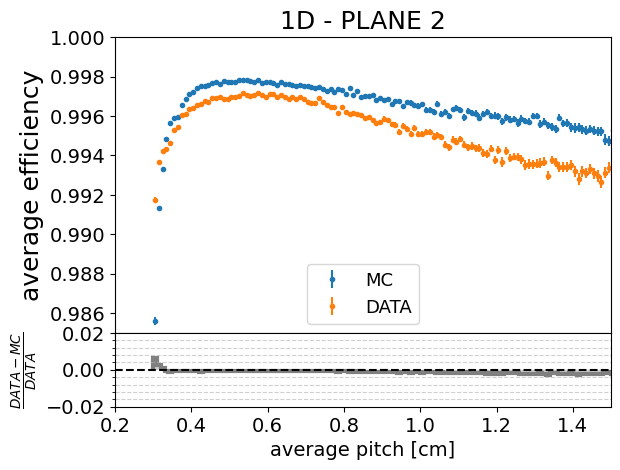

In [36]:
PLANE = 2

mask_MC = (plane_MC_1d == PLANE) & (max_buco_MC_1d < 10)
mask_DATA = (plane_DATA_1d == PLANE) & (max_buco_DATA_1d < 10)

#MC
average_pitch_MC_1d = avg_pitch_MC_1d[mask_MC]
eff_MC_1d = hit_wires_MC_1d[mask_MC]/tot_wires_MC_1d[mask_MC]

mean_y_MC_1d, x_edges_MC_1d, binnumber_MC_1d = binned_statistic(average_pitch_MC_1d, eff_MC_1d, statistic='mean', bins=400, range=(0,4))
std_y_MC_1d, _, _ = binned_statistic(average_pitch_MC_1d, eff_MC_1d, statistic='std', bins=400, range=(0,4))

x_centers_MC_1d = 0.5 * (x_edges_MC_1d[:-1] + x_edges_MC_1d[1:])

counts_MC_1d, _ = np.histogram(average_pitch_MC_1d, bins=400, range=(0,4))
err_y_MC_1d = std_y_MC_1d / np.sqrt(counts_MC_1d)

#DATA

average_pitch_DATA_1d = avg_pitch_DATA_1d[mask_DATA]
eff_DATA_1d = hit_wires_DATA_1d[mask_DATA]/tot_wires_DATA_1d[mask_DATA]

mean_y_DATA_1d, x_edges_DATA_1d, binnumber_DATA_1d = binned_statistic(average_pitch_DATA_1d, eff_DATA_1d, statistic='mean', bins=400, range=(0,4))
std_y_DATA_1d, _, _ = binned_statistic(average_pitch_DATA_1d, eff_DATA_1d, statistic='std', bins=400, range=(0,4))

x_centers_DATA_1d = 0.5 * (x_edges_DATA_1d[:-1] + x_edges_DATA_1d[1:])

counts_DATA_1d, _ = np.histogram(average_pitch_DATA_1d, bins=400, range=(0,4))
err_y_DATA_1d = std_y_DATA_1d / np.sqrt(counts_DATA_1d)

data_mc_ratio = [(data - mc)/data for data,mc in zip(mean_y_DATA_1d,mean_y_MC_1d)]

fig = plt.figure()

gs = fig.add_gridspec(2, 1, height_ratios=[8,2], hspace=0)

plt.subplot(gs[0])

plt.errorbar(x_centers_MC_1d, mean_y_MC_1d, yerr=err_y_MC_1d, fmt='.', label = r'MC')
plt.errorbar(x_centers_DATA_1d, mean_y_DATA_1d, yerr=err_y_DATA_1d, fmt='.', label = r'DATA')

plt.ylabel('average efficiency', fontsize=18)
plt.yticks(fontsize=14)
ax = plt.gca()
labels = ax.get_yticklabels()
labels[0].set_visible(False)
plt.title("1D - PLANE {}".format(PLANE), fontsize = 18)
plt.legend(loc = 'lower center', fontsize = 13)
plt.xlim(0.2,1.5)
plt.ylim(0.985,1.)

plt.setp(plt.gca().get_xticklabels(), visible=False)
plt.gca().tick_params(labelbottom=False)

plt.subplot(gs[1])

dx = x_centers_MC_1d[1] - x_centers_MC_1d[0]

edges = np.concatenate([
    [x_centers_MC_1d[0] - dx/2],
    x_centers_MC_1d[:-1] + dx/2,
    [x_centers_MC_1d[-1] + dx/2]
])

plt.stairs(data_mc_ratio,edges,fill=False,lw=3,color='gray')

plt.fill_between(
edges[:-1],
0,
data_mc_ratio,
step='post',
alpha=0.4,
color='gray',
lw=0
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlim(0.2,1.5)
plt.ylim(-0.02, 0.02)

plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))
plt.grid(axis='y', which='minor', linestyle='--', alpha=0.6)


plt.axhline(0, color='black', linestyle='--')
    
plt.xlabel('average pitch [cm]', fontsize=14)
plt.ylabel(r'$\frac{DATA - MC}{DATA}$', fontsize=14)

plt.savefig(f"1D_plane{PLANE}_hit_efficiency_ratio.pdf", format ='pdf', bbox_inches = "tight")

